# AlexNet fc6 → PCA latents

Extract AlexNet fc6 (relu6) activations for every image in the ImageNet64 train/val sets, reduce to the top 50 principal components, and save the result as a fixed per-image latent — a drop-in replacement for the β-VAE latent used to condition the diffusion U-Net (`forward(x, t, z)`).

PCA is fit on a random subsample (fits in RAM), then applied to the full dataset in a single streaming pass that never materializes all activations at once — see "Stream the full train/val sets" below. Latents are written directly into the ImageNet64 `data_dir`, row-aligned with `train_images.npy` / `val_images.npy`, and picked up automatically by `build_imagenet64_dataloaders` / `DiffusionTrainer`.

In [1]:
import os
import sys
import json

import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import models, transforms
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt

In [2]:
REPO_ROOT = ".."
sys.path.insert(0, REPO_ROOT)

import importlib.metadata
if not hasattr(importlib.metadata, '_patched'):

    _original_version = importlib.metadata.version
    def _patched_version(name):
        try:
            return _original_version(name)
        except importlib.metadata.PackageNotFoundError:
            return 'unknown'
    importlib.metadata.version = _patched_version
    importlib.metadata._patched = True

from data_utils import build_tiny_imagenet_dataloaders

## Config

In [3]:
# holds train_images.npy / val_images.npy
# DATA_DIR = "/content/data/imagenet64"  
DATA_DIR = os.path.join(REPO_ROOT, "data/tiny-imagenet-200")

# AlexNet's native input resolution
IMAGE_SIZE = 224          
BATCH_SIZE = 64

# latent_dim to use in the diffusion config
N_COMPONENTS = 50         

# random train images used to fit PCA (fits comfortably in RAM)
SUBSAMPLE_SIZE = 50  
SEED = 42
OUTPUT_DIR = os.path.join(REPO_ROOT, "data/imagenet64_alexnet_fc6_pca_latents")

os.makedirs(OUTPUT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
# subprocess.run([
#     "python", os.path.join(REPO_ROOT, "scripts/prepare_imagenet64_dataset.py"),
#     "--drive_train_part1_zip", os.path.join(REPO_ROOT, "data/imagenet64/Imagenet64_train_part1.zip"),
#     "--drive_train_part2_zip", os.path.join(REPO_ROOT, "data/imagenet64/Imagenet64_train_part2.zip"),
#     "--drive_val_zip", os.path.join(REPO_ROOT, "data/imagenet64/Imagenet64_val.zip"),
#     "--data_dir", DATA_DIR,
# ], check=True)

## Load AlexNet, hook fc6 (relu6)

`classifier` is `[Dropout, Linear(9216→4096) fc6, ReLU, Dropout, Linear(4096→4096) fc7, ReLU, Linear(4096→1000)]`.
"fc6 activations" conventionally means the *post-ReLU* output (`relu6`), i.e. the output of `classifier[2]` — that's what the hook below captures.

In [5]:
alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1).to(device).eval()
for p in alexnet.parameters():
    p.requires_grad_(False)

_fc6_activation = {"value": None}

def _fc6_hook(module, inp, out):
    _fc6_activation["value"] = out.detach()

hook_handle = alexnet.classifier[2].register_forward_hook(_fc6_hook)  # relu6 output

# AlexNet's pretrained weights expect ImageNet-normalized input; build_imagenet64_dataloaders
# only resizes (64→224) and gives [0,1] tensors, so normalize per-batch here.
imagenet_normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

@torch.no_grad()
def extract_fc6_batch(batch) -> np.ndarray:
    """Run one batch through AlexNet, return its fc6 (relu6) activations as a numpy array.
    O(1) memory regardless of dataset size — only ever holds one batch's activations.

    Guards against (image, latent) tuples: build_imagenet64_dataloaders auto-detects and
    switches to yielding (image, latent) pairs once train_latents.npy/val_latents.npy exist,
    e.g. if this notebook is re-run after a previous pass already wrote them.
    """
    images = batch[0] if isinstance(batch, (list, tuple)) else batch
    images = imagenet_normalize(images).to(device)
    alexnet(images)
    return _fc6_activation["value"].cpu().numpy()

## Build train/val dataloaders (unshuffled, for encoding)

Reuses `build_imagenet64_dataloaders` directly with `shuffle_train=False` — this makes both loaders unshuffled with no dropped batch, so index `i` here matches row `i` of `train_images.npy` / `val_images.npy`, the same row order the streaming pass below writes latents back into. `extract_fc6_batch` guards against the (image, latent) tuples this function would start yielding if latents already existed on disk (e.g. a re-run after a previous pass already wrote them).

In [6]:
# train_encode_dl, val_encode_dl = build_imagenet64_dataloaders(
#     DATA_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle_train=False, num_workers=0,
# )

train_encode_dl, val_encode_dl = build_tiny_imagenet_dataloaders(
    DATA_DIR, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, shuffle_train=False, num_workers=0,
)

Tiny ImageNet — Train: 99000 images (1547 batches/epoch) | Test: 11000 images (172 batches)


## Fit PCA on a random subsample of train

PCA's top-50 subspace is stable with far fewer than all 1.28M images. Fit it on a random subsample that fits comfortably in RAM (`SUBSAMPLE_SIZE` images × 4096 floats ≈ a few hundred MB–1GB), then apply the fitted transform to the full dataset in the streaming pass further down — the full `[N, 4096]` activation matrix (~21 GB for the whole train split) is never materialized.

In [7]:
n_train = len(train_encode_dl.dataset)
rng = np.random.default_rng(SEED)
subsample_idx = np.sort(rng.choice(n_train, size=min(SUBSAMPLE_SIZE, n_train), replace=False)).tolist()

subsample_dl = DataLoader(
    Subset(train_encode_dl.dataset, subsample_idx),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True,
)

subsample_fc6 = np.concatenate([extract_fc6_batch(batch) for batch in subsample_dl], axis=0)
print(f"Subsample fc6 activations: {subsample_fc6.shape}")

/home/jhanliufu/RutishauserLab/DiffusionBANMap/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Subsample fc6 activations: (50, 4096)


## Standardize + PCA

fc6 units are post-ReLU (non-negative, very different per-unit scales), so z-score before PCA — otherwise a handful of high-variance units would dominate the top PCs. Fit on the random subsample extracted above.

In [8]:
# subsample_fc6 = np.random.rand(50, 4096)
# print(subsample_fc6.shape)

In [9]:
scaler = StandardScaler()
fc6_scaled = scaler.fit_transform(subsample_fc6)

pca = PCA(n_components=N_COMPONENTS, random_state=SEED, svd_solver="randomized")
# pca = PCA(n_components=50, random_state=42, svd_solver="randomized")

In [10]:
pca.fit(fc6_scaled)

print(f"Fitted PCA on {subsample_fc6.shape[0]:,} images")
print(f"Explained variance (top {50} PCs): {pca.explained_variance_ratio_.sum():.3f}")

Fitted PCA on 50 images
Explained variance (top 50 PCs): 1.000


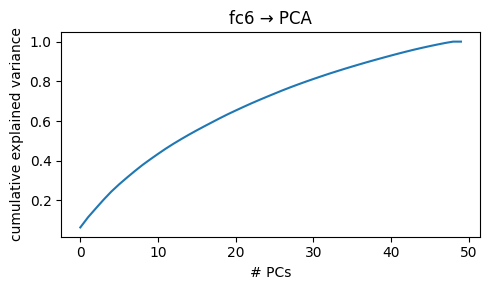

In [11]:
plt.figure(figsize=(5, 3))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("# PCs")
plt.ylabel("cumulative explained variance")
plt.title("fc6 → PCA")
plt.tight_layout()
plt.show()

## Stream the full train/val sets through AlexNet → PCA

One batch of raw fc6 activations lives in memory at a time — each batch is transformed (`scaler` → `pca`) immediately and its 50-d rows written into a preallocated latents array on disk, so the full `[N, 4096]` activation matrix (~21 GB for the whole train split) is never materialized. Written directly into `DATA_DIR` as `train_latents.npy` / `val_latents.npy`, row-aligned with `train_images.npy` / `val_images.npy` — `build_imagenet64_dataloaders` picks these up automatically (see below).

This is the expensive, unavoidable part (one AlexNet forward pass per image, ~1.28M for train) — run this on a GPU runtime if at all possible. Resumable: re-running this cell skips any split whose latents file already exists (atomic tmp-then-rename, same pattern as `prepare_imagenet64_dataset.py`).

In [ ]:
def _stream_latents(encode_dl: DataLoader, out_path: str) -> None:
    if os.path.exists(out_path):
        print(f"Already extracted: {out_path}")
        return
    n = len(encode_dl.dataset)
    tmp_path = out_path + ".tmp"
    out = np.lib.format.open_memmap(tmp_path, mode="w+", dtype=np.float32, shape=(n, N_COMPONENTS))
    offset = 0
    for batch in encode_dl:
        fc6_batch = extract_fc6_batch(batch)
        z = pca.transform(scaler.transform(fc6_batch)).astype(np.float32)
        out[offset:offset + z.shape[0]] = z
        offset += z.shape[0]
        if offset % (BATCH_SIZE * 100) < BATCH_SIZE or offset == n:
            print(f"  {offset:,}/{n:,} latents written → {out_path}")
    out.flush()
    del out
    os.rename(tmp_path, out_path)
    print(f"Done: {out_path}")


train_latents_path = os.path.join(OUTPUT_DIR, "train_latents.npy")
val_latents_path = os.path.join(OUTPUT_DIR, "val_latents.npy")

_stream_latents(train_encode_dl, train_latents_path)
_stream_latents(val_encode_dl, val_latents_path)

hook_handle.remove()

## Save PCA/scaler artifacts + manifest

Latents themselves already live in `DATA_DIR` (used positionally by the trainer, see below). This saves the fitted `StandardScaler`/`PCA` — for mapping any new image into the same latent space later — and a manifest, to a repo-relative, more persistent location.

**Note:** `DATA_DIR` is Colab's local runtime disk (`/content/...`) — copy `train_latents.npy` / `val_latents.npy` to Drive if you want them to survive a runtime restart; regenerating them means re-running the streaming AlexNet pass above.

In [ ]:
joblib.dump(scaler, os.path.join(OUTPUT_DIR, "fc6_scaler.joblib"))
joblib.dump(pca, os.path.join(OUTPUT_DIR, "fc6_pca.joblib"))

with open(os.path.join(OUTPUT_DIR, "manifest.json"), "w") as f:
    json.dump({
        "data_dir": DATA_DIR,
        "n_train": len(train_encode_dl.dataset),
        "n_val": len(val_encode_dl.dataset),
        "subsample_size": int(subsample_fc6.shape[0]),
        "n_components": N_COMPONENTS,
        "explained_variance_ratio_sum": float(pca.explained_variance_ratio_.sum()),
        "train_latents_path": train_latents_path,
        "val_latents_path": val_latents_path,
    }, f, indent=2)

print(f"Saved scaler + PCA + manifest → {OUTPUT_DIR}")
print(f"Saved latents → {train_latents_path}, {val_latents_path}")

## Using these latents to condition diffusion training

Set `latent_dim: 50` in the diffusion config. No other config changes needed:

- `build_imagenet64_dataloaders` (`data_utils.py`) auto-detects `train_latents.npy` / `val_latents.npy` next to `train_images.npy` / `val_images.npy` in `data_dir`, and switches to yielding `(image, latent)` pairs instead of plain image tensors.
- `DiffusionTrainer` (`scripts/diffusion_trainer.py`) auto-detects the same way — `_unpack_batch` checks whether a batch is a tuple, and if so feeds that latent straight into `_get_conditioning` instead of the unconditional-zeros / on-the-fly-VAE-encode path.

Set `cfg_uncond_prob > 0` in the config if you also want classifier-free guidance usable at sampling time.